In [1]:
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# text processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [2]:
df = pd.read_excel("P652-Dataset.xlsx")

df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [3]:
df.shape

(1440, 3)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [5]:
df.isnull().sum()

title     0
rating    0
body      0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
df["review"] = df["title"] + " " + df["body"]

df.head()

,title,rating,body,review
0,Horrible product,1,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Camera quality is not like 48 megapixel Camera...
2,Overall,4,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...


In [8]:
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["sentiment"] = df["rating"].apply(sentiment_label)

In [9]:
df["sentiment"].value_counts()

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

# **Sentiment Distribution Graph**




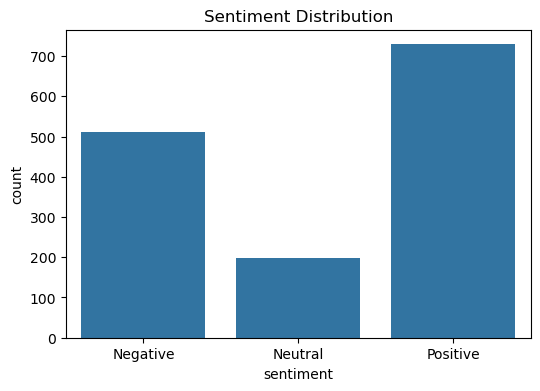

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="sentiment", data=df)

plt.title("Sentiment Distribution")
plt.show()

# **Rating Distribution Histogram**

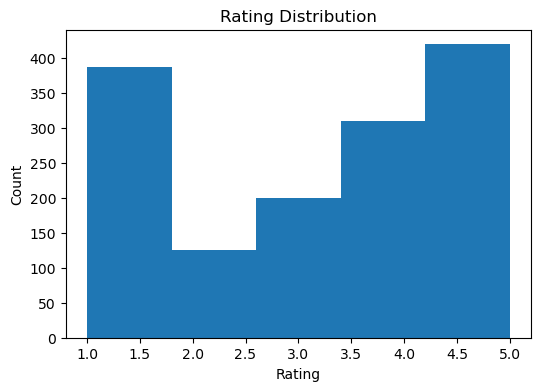

In [13]:
plt.figure(figsize=(6,4))

plt.hist(df["rating"], bins=5)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

# **Box Plot for Ratings**

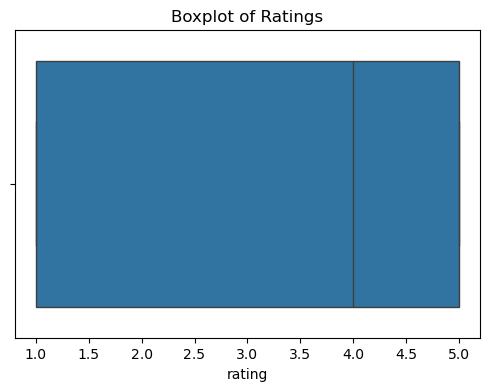

In [15]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["rating"])

plt.title("Boxplot of Ratings")

plt.show()

# **Review Length Analysis**

In [17]:
df["review_length"] = df["review"].apply(len)

df.head()

,title,rating,body,review,sentiment,review_length
0,Horrible product,1,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...,Negative,76
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Camera quality is not like 48 megapixel Camera...,Neutral,61
2,Overall,4,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt...",Positive,411
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...,Negative,394
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...,Negative,209


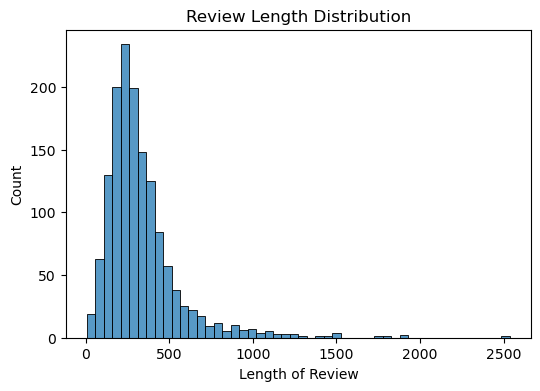

In [18]:
plt.figure(figsize=(6,4))

sns.histplot(df["review_length"], bins=50)

plt.title("Review Length Distribution")
plt.xlabel("Length of Review")

plt.show()

# **Sentiment vs Review Length**

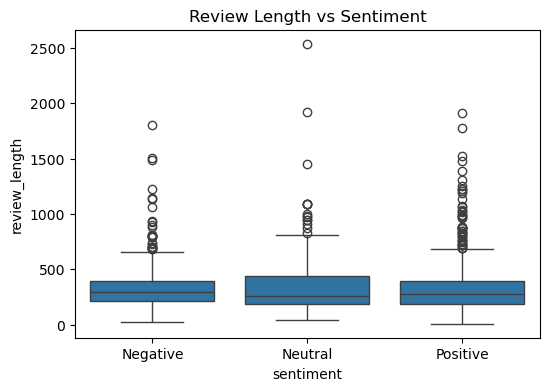

In [20]:
plt.figure(figsize=(6,4))

sns.boxplot(x="sentiment", y="review_length", data=df)

plt.title("Review Length vs Sentiment")

plt.show()

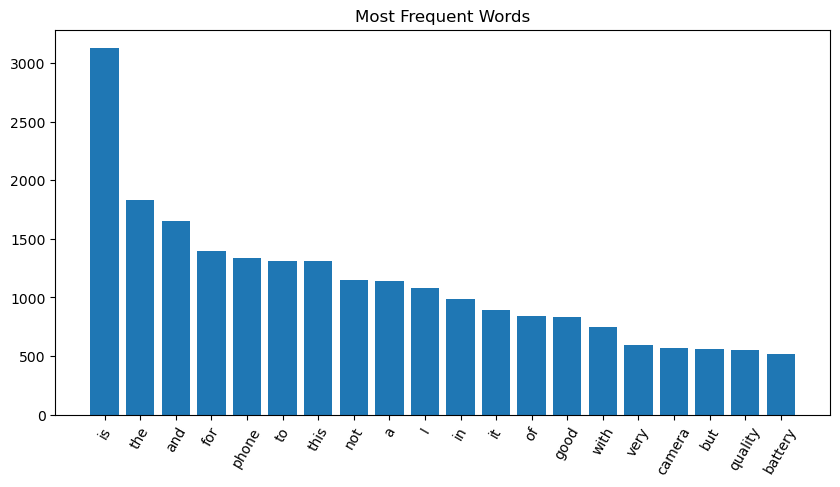

In [21]:
from collections import Counter

all_words = " ".join(df["review"]).split()

common_words = Counter(all_words).most_common(20)

words = [i[0] for i in common_words]
counts = [i[1] for i in common_words]

plt.figure(figsize=(10,5))

plt.bar(words, counts)

plt.xticks(rotation=60)

plt.title("Most Frequent Words")

plt.show()

# **Word Cloud**

In [23]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: wordcloud in c:\users\dell\anaconda3\lib\site-packages (1.9.4)




[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


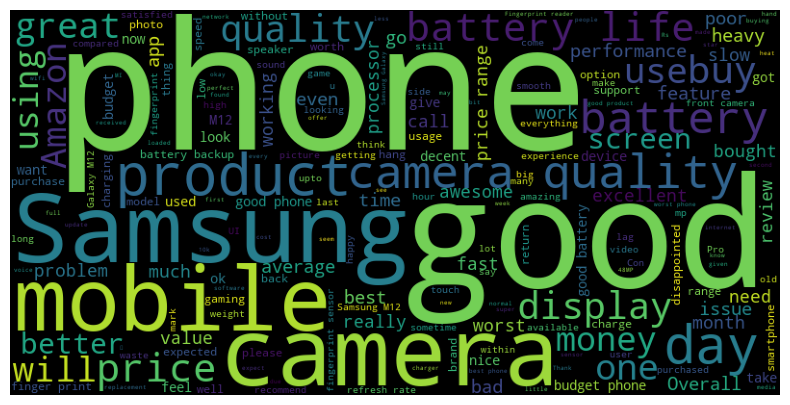

In [24]:
from wordcloud import WordCloud

text = " ".join(df["review"])

wordcloud = WordCloud(width=800,height=400).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")

plt.show()

# **Feature Engineering**

In [26]:
df["review"] = df["title"] + " " + df["body"]

This converts the numeric rating into sentiment classes.

In [28]:
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["sentiment"] = df["rating"].apply(sentiment_label)

In [29]:
df["sentiment"].value_counts()

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

# **TEXT CLEANING**

# **Convert Text to Lowercase**

In [32]:
df["review"] = df["review"].str.lower()

# **Remove Special Characters**

In [34]:
import re

df["review"] = df["review"].apply(lambda x: re.sub(r'[^a-zA-Z ]','',x))

# **Tokenization**

In [36]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [37]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [38]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["review"].apply(word_tokenize)

# **Stopword Removal**

In [40]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["tokens"] = df["tokens"].apply(
    lambda words: [w for w in words if w not in stop_words]
)

# **Lemmatization**

In [42]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df["tokens"] = df["tokens"].apply(
    lambda words: [lemmatizer.lemmatize(w) for w in words]
)

# **Join Tokens**


In [44]:
df["clean_review"] = df["tokens"].apply(lambda x: " ".join(x))

# **Additional Feature (Review Length)**

In [46]:
df["review_length"] = df["clean_review"].apply(len)

# **Convert Text to Numerical Features (TF-IDF)**

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_review"])

y = df["sentiment"]

# **Train Test Split**


In [50]:
from sklearn.model_selection import train_test_split

X = df["clean_review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Convert Text → Numerical (TF-IDF)**

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# **Import Models**

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [55]:
models = {

    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()

}

# **Train + Evaluate All Models**

In [57]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():

    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

results

{'Logistic Regression': 0.7916666666666666,
 'Naive Bayes': 0.7118055555555556,
 'SVM': 0.7951388888888888,
 'Decision Tree': 0.6041666666666666,
 'Random Forest': 0.7638888888888888,
 'KNN': 0.6041666666666666,
 'Gradient Boosting': 0.7638888888888888}

# **Compare Models**

In [59]:
import pandas as pd

model_results = pd.DataFrame(results.items(), columns=["Model","Accuracy"])

model_results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,SVM,0.795139
0,Logistic Regression,0.791667
4,Random Forest,0.763889
6,Gradient Boosting,0.763889
1,Naive Bayes,0.711806
3,Decision Tree,0.604167
5,KNN,0.604167


# **Visualization of Model Comparison**

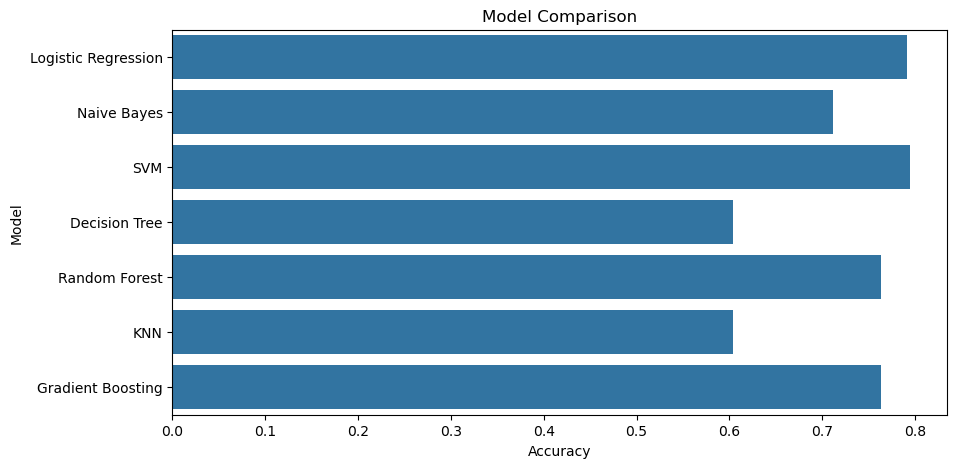

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.barplot(x="Accuracy", y="Model", data=model_results)

plt.title("Model Comparison")

plt.show()

# **Final Evaluation of Best Model**

In [63]:
best_model_name = max(results, key=results.get)

best_model_name

'SVM'

# **Train Final Model**

In [65]:
best_model = models[best_model_name]

best_model.fit(X_train_tfidf, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


# **Confusion Matrix**

In [67]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = best_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89       111
     Neutral       0.00      0.00      0.00        44
    Positive       0.73      0.98      0.84       133

    accuracy                           0.80       288
   macro avg       0.54      0.62      0.58       288
weighted avg       0.68      0.80      0.73       288



C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [74]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    
    # convert to lowercase
    text = text.lower()
    
    # remove URLs
    text = re.sub(r'http\S+', '', text)
    
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # remove numbers
    text = re.sub(r'\d+', '', text)
    
    # tokenize
    words = text.split()
    
    # remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(words)

# **Test With Custom Review**

In [77]:
sample = ["This product is amazing and works perfectly"]

sample_clean = [clean_text(text) for text in sample]

sample_vec = tfidf.transform(sample_clean)

prediction = best_model.predict(sample_vec)

print(prediction)

['Positive']


In [79]:
import pickle

# Save model
pickle.dump(best_model, open("svm_model.pkl", "wb"))

# Save tfidf vectorizer
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))